# C07 — A Lei como Dado: Análise do Microssistema Penal

**Disciplina:** Sistemas Cognitivos com Large Language Models (INFNET, 26E2_3)
**Autor:** Anderson Felipe Paixão Corrêa
**Projeto:** Letra da Lei

Este notebook vai além dos cinco pontos exigidos pelo projeto: aqui a própria legislação é
tratada como um grafo de dados — normas, dispositivos e as relações de alteração/revogação
entre eles, extraídas das anotações inline do texto oficial do Planalto — o que permite
agregações, contagens e uma visualização de rede sobre o corpus normativo, como se faria
com qualquer outro dataset.

Como em `c03_embeddings_busca.ipynb`, este notebook reaproveita módulos já implementados e
testados do projeto: a lógica de análise (contagens, agregações, construção do grafo) vive
no código-fonte, não aqui.

O que será demonstrado:

1. Construção do grafo sobre o **corpus completo** (9 normas, 2.304 artigos).
2. Linha do tempo de alterações por década, com a narrativa histórica por trás dos picos.
3. Resumo de vigência por norma e distribuição por nível hierárquico (com a ressalva de
   que decreto-lei, lei ordinária e medida provisória compartilham o mesmo *rank*).
4. Dispositivos mais alterados do microssistema.
5. Visualização de rede do grafo normas/dispositivos.


## Setup e construção do grafo

Carregamos o corpus completo (todas as 9 normas do registro) e construímos o grafo de
normas e dispositivos: cada norma e cada artigo vira um nó, e cada anotação inline do texto
oficial do Planalto (`(Redação dada por...)`, `(Incluído por...)`, `(Revogado por...)`)
vira uma aresta de alteração ou revogação — fatos verificados diretamente do texto oficial,
com o maior grau de confiança possível.


In [1]:
%matplotlib inline
import sys
import time
from pathlib import Path

_repo_root = Path.cwd()
if not (_repo_root / "direito_dados").exists():
    _repo_root = Path(__file__).resolve().parent if "__file__" in globals() else _repo_root
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from direito_dados.corpus import load_corpus, NORMS
from direito_dados.graph import build_graph, EdgeKind, NodeKind
from direito_dados.analytics.timeline import amendments_by_year, amendments_by_decade, amendments_per_norm
from direito_dados.analytics.summary import vigencia_summary, hierarchy_distribution, most_amended_articles
from direito_dados.analytics.network import to_network_data
from direito_dados.analytics.plots import plot_amendments_by_decade, plot_hierarchy_pyramid, plot_network

t0 = time.time()
corpus = load_corpus("data/raw")
graph = build_graph(corpus)
print(f"Corpus + grafo construídos em {time.time() - t0:.2f}s")
print(f"Normas: {len(corpus.norms)}   Artigos: {len(corpus.all_articles())}")
print(f"Nós do grafo: {len(graph.nodes)}   Arestas: {len(graph.edges)}")
print(f"  NORM: {len(graph.nodes_of_kind(NodeKind.NORM))}   PROVISION: {len(graph.nodes_of_kind(NodeKind.PROVISION))}")
print(f"  AMENDS: {len(graph.edges_of_kind(EdgeKind.AMENDS))}   REVOKES: {len(graph.edges_of_kind(EdgeKind.REVOKES))}")


Corpus + grafo construídos em 0.05s
Normas: 9   Artigos: 2304
Nós do grafo: 2375   Arestas: 4727
  NORM: 337   PROVISION: 2038
  AMENDS: 4453   REVOKES: 274


## 1. Linha do tempo de alterações

Cada aresta `AMENDS`/`REVOKES` carrega o ano extraído da anotação Planalto. Agregada por
década, essa linha do tempo é essencialmente "de graça" — não exige nenhum processamento
adicional além do que o grafo já guarda.


1940s:    26 alterações/revogações
1950s:    16 alterações/revogações
1960s:    15 alterações/revogações
1970s:    49 alterações/revogações
1980s:   268 alterações/revogações
1990s:   422 alterações/revogações
2000s:  1283 alterações/revogações
2010s:  1199 alterações/revogações
2020s:   970 alterações/revogações


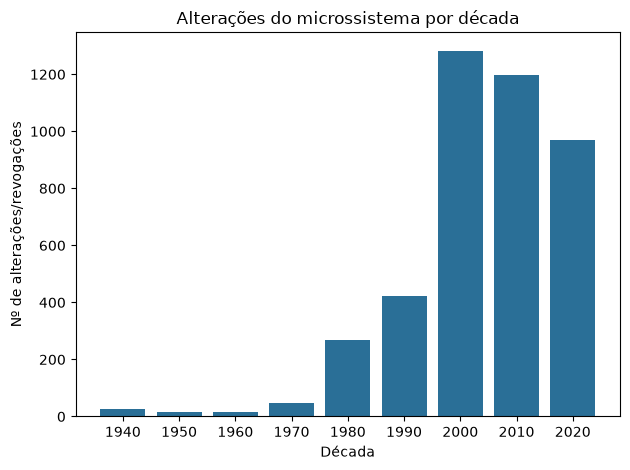

In [2]:
by_decade = amendments_by_decade(graph)
for decade in sorted(by_decade):
    print(f"{decade}s: {by_decade[decade]:>5} alterações/revogações")

fig = plot_amendments_by_decade(by_decade)
fig

In [3]:
by_year = amendments_by_year(graph)
by_norm_2019 = {}
for e in graph.edges:
    if e.attrs.get("year") == 2019:
        norm_id = e.dst.split(":")[0]
        by_norm_2019[norm_id] = by_norm_2019.get(norm_id, 0) + 1

print("1984:", by_year.get(1984), "alterações (todas no CP)")
print("2019:", by_year.get(2019), "alterações, por norma:", dict(sorted(by_norm_2019.items(), key=lambda kv: -kv[1])))

1984: 261 alterações (todas no CP)
2019: 548 alterações, por norma: {'L11343': 223, 'CPP': 150, 'CF': 72, 'CP': 40, 'LEP': 30, 'L11340': 19, 'L8072': 14}


**Leitura do gráfico e da narrativa histórica:**

- **Década de 1980 (268 alterações, das quais 261 datadas de 1984):** a **reforma da Parte
  Geral do Código Penal** (Lei nº 7.209/1984) — a maior reescrita estrutural do CP desde
  1940, que introduziu o sistema atual de aplicação de pena, regimes de cumprimento e
  circunstâncias atenuantes/agravantes. O grafo captura isso como um único evento em massa
  concentrado em um ano.
- **Anos 2000 e 2010 (1.283 e 1.199 alterações):** o período de maior produção legislativa
  do microssistema — sucessivas emendas constitucionais e leis extravagantes (Lei de
  Drogas de 2006, Maria da Penha de 2006, atualizações de crimes hediondos), refletindo a
  expansão do direito penal brasileiro nesse intervalo.
- **2019 (548 alterações — um dos anos de maior atividade legislativa do corpus):** não é
  um evento único. É a sobreposição de pelo menos três reformas simultâneas de grande
  porte: o **Pacote Anticrime** (Lei nº 13.964/2019, concentrado em CPP e CP — juiz das
  garantias, prisão em flagrante, banco de perfis genéticos), a **Reforma da Previdência**
  (EC nº 103/2019, concentrada em dezenas de artigos da CF) e uma extensa reforma da **Lei
  de Drogas** quanto a apreensão e destinação de bens (Lei nº 13.840/2019). O breakdown por
  norma acima mostra exatamente essa composição — nenhuma norma isolada explica o pico
  sozinha.


## 2. Resumo de vigência por norma e distribuição hierárquica

Nesta seção resumimos, por norma, quantos artigos estão vigentes, alterados ou revogados, e
também contamos quantas normas do corpus caem em cada nível hierárquico (constituição, lei
ordinária, etc.).


In [4]:
summary = vigencia_summary(corpus)
print(f"{'Norma':<10}{'Vigente':>10}{'Alterado':>10}{'Revogado':>10}")
for norm_id, counts in summary.items():
    print(f"{norm_id:<10}{counts['vigente']:>10}{counts['alterado']:>10}{counts['revogado']:>10}")

total_in_force = sum(c["vigente"] for c in summary.values())
total_amended = sum(c["alterado"] for c in summary.values())
total_revoked = sum(c["revogado"] for c in summary.values())
print(f"\n{'TOTAL':<10}{total_in_force:>10}{total_amended:>10}{total_revoked:>10}")

Norma        Vigente  Alterado  Revogado
CF               205       307         0
CP               134       272        25
CPP              526       288        35
LEP              165        52         2
L11343            60        54         0
L11340            35        25         0
L8072             12         2         0
DL3688            61        14         0
LINDB             11        19         0

TOTAL           1209      1033        62


Distribuição por nível hierárquico: {'CONSTITUICAO': 1, 'LEI_ORDINARIA': 8}


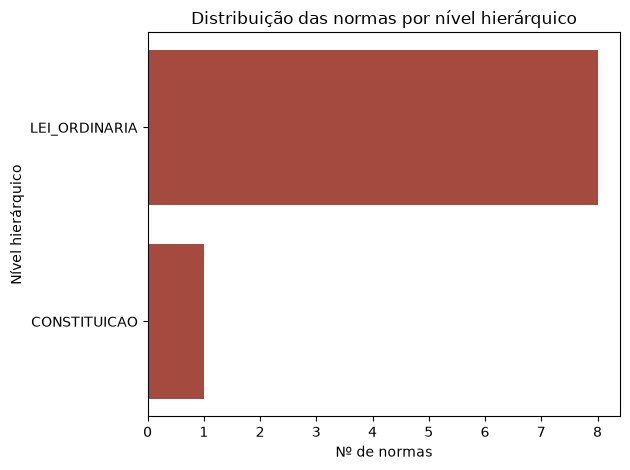

In [5]:
dist = hierarchy_distribution(corpus)
print("Distribuição por nível hierárquico:", dist)

fig = plot_hierarchy_pyramid(dist)
fig


**Ressalva sobre a distribuição hierárquica.** A classificação por nível hierárquico usa
uma enumeração (`HierarchyLevel`) em que `LEI_ORDINARIA`, `DECRETO_LEI` e
`MEDIDA_PROVISORIA` compartilham o **mesmo valor numérico (3)** — corretamente, do ponto de
vista de *lex superior*: nenhuma dessas três espécies normativas prevalece sobre outra só
por classe (a resolução de conflito entre elas depende de critérios materiais como *lex
posterior* e *lex specialis*, tratados em outro módulo do projeto, não pela hierarquia
isolada). Mas isso tem uma consequência técnica direta: em Python, membros de enumeração
com valores duplicados viram **aliases** do primeiro membro definido — então, internamente,
decreto-lei acaba reclassificado como `"LEI_ORDINARIA"`. É por isso que o bucket
`LEI_ORDINARIA` acima concentra 8 das 9 normas: ele inclui tanto leis ordinárias
propriamente ditas (LEP, L11343, L11340, L8072) quanto decretos-lei pré-1988 com força de
lei ordinária (CP, CPP, DL3688, LINDB). Somente a CF (nível 1, sem par) aparece isolada. O
agrupamento é semanticamente correto — é assim que o direito brasileiro trata decreto-lei
recepcionado — mas quem lê o gráfico sem este contexto pode achar, por engano, que só
existe uma lei ordinária no corpus.


## 3. Dispositivos mais alterados

Aqui listamos os dispositivos ordenados pelo número de alterações e revogações que cada um
recebeu — uma proxy direta de "quanto um dispositivo foi mexido" ao longo do tempo.


In [6]:
top10 = most_amended_articles(graph, top=10)
print(f"{'Dispositivo':<16}{'Nº de alterações'}")
for provision_id, n in top10:
    print(f"{provision_id:<16}{n}")


Dispositivo     Nº de alterações
CF:art40        75
CF:art100       74
CF:art60        66
CF:art156-A     63
CF:art97        52
L11343:art8     43
CF:art107       42
CF:art101       41
CF:art155       41
CF:art201       39


O topo do ranking do corpus completo é dominado pela **CF** (art. 40 — regime próprio de
previdência dos servidores, art. 100 — precatórios, art. 60 — processo legislativo de
emendas constitucionais): esperado, já que emendas constitucionais frequentemente
retocam os mesmos artigos estruturais repetidas vezes. Olhando só para o Código Penal
(recorte mais alinhado ao domínio penal deste projeto), o topo já conta outra história —
os crimes mais comuns e mais frequentemente reformados pelo legislador ao longo de 85 anos:


In [7]:
corpus_cp = load_corpus("data/raw", specs=[NORMS["CP"]])
graph_cp = build_graph(corpus_cp)
top10_cp = most_amended_articles(graph_cp, top=10)
print(f"{'Dispositivo':<16}{'Nº de alterações'}")
for provision_id, n in top10_cp:
    print(f"{provision_id:<16}{n}")


Dispositivo     Nº de alterações
CP:art121       22
CP:art157       22
CP:art129       20
CP:art7         20
CP:art155       18
CP:art171       17
CP:art121-A     14
CP:art337-A     14
CP:art92        14
CP:art122       13


`CP:art121` (homicídio) e `CP:art157` (roubo) empatam no topo — os dois crimes contra a
pessoa e contra o patrimônio mais centrais do Código, sucessivamente reformados (Lei dos
Crimes Hediondos, Pacote Anticrime, entre outras) para endurecer penas e criar
qualificadoras. `CP:art171` (estelionato) — o mesmo artigo que a busca só-densa não
recuperou na notebook `c03` — também aparece no top-10, reforçando que é um dispositivo
central e ativamente atualizado, não marginal.


## 4. Visualização de rede

O grafo completo tem os nós e arestas impressos na célula de setup acima (2.375 nós,
milhares de arestas) — ilegível em um único plot. Além disso, a extração dos dados de rede
exclui nós externos por padrão: como toda aresta de alteração/revogação vai de uma *norma
emendadora* (que quase sempre é externa ao corpus — ex. "Lei nº 13.964, de 2019", que não é
uma das 9 normas modeladas) para um *dispositivo* de uma das 9 normas, excluir nós externos
remove também **todas as arestas** — o grafo resultante fica com nós, mas sem conexão
nenhuma. Por isso incluímos os nós externos abaixo, o que reintroduz as normas emendadoras
como nós (rotulados com a lei/ano de origem) e restaura a estrutura de rede.

Para manter o desenho legível, plotamos o subgrafo do **Código Penal** — recorte que
concentra as reformas mais discutidas na seção 1 (1984 e o Pacote Anticrime de 2019) — em
vez do grafo completo (que incluiria a CF, com centenas de nós dominados por emendas
constitucionais e tornaria o desenho ilegível).


Grafo completo (include_external=True):  2375 nós, 4727 arestas
Grafo completo (include_external=False): 2047 nós, 0 arestas (todas as arestas somem)
Subgrafo CP (include_external=True):     525 nós, 1026 arestas


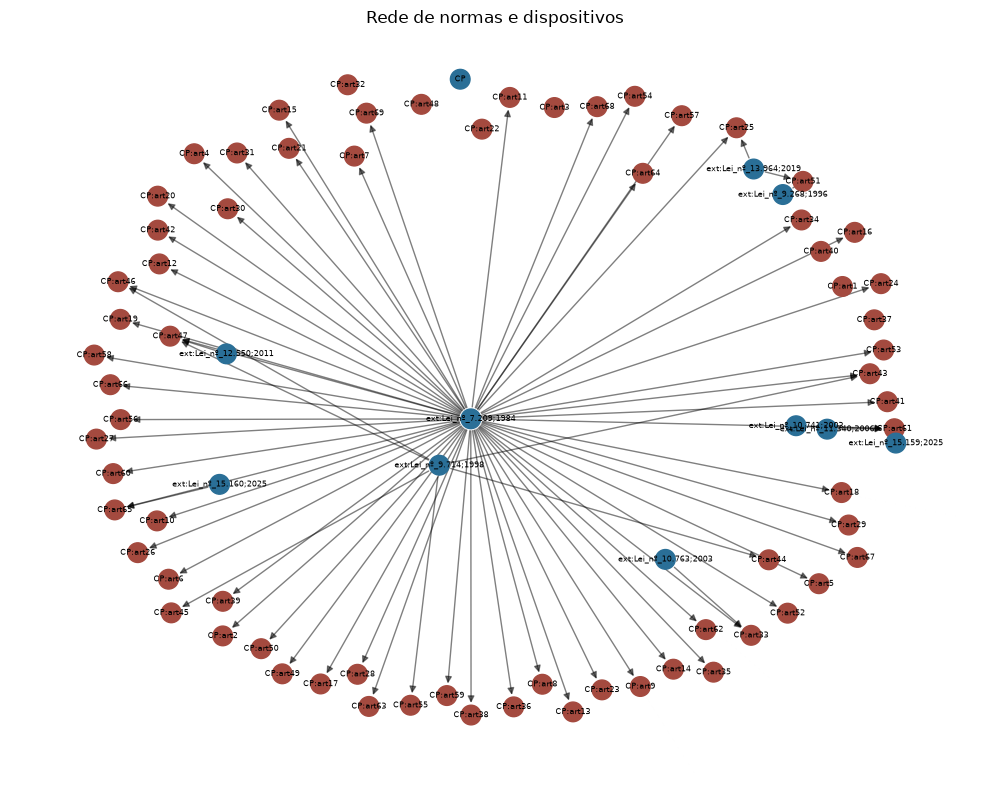

In [8]:
network_full = to_network_data(graph, include_external=True)
network_full_no_ext = to_network_data(graph, include_external=False)
print(f"Grafo completo (include_external=True):  {len(network_full['nodes'])} nós, {len(network_full['edges'])} arestas")
print(f"Grafo completo (include_external=False): {len(network_full_no_ext['nodes'])} nós, {len(network_full_no_ext['edges'])} arestas (todas as arestas somem)")

network_cp = to_network_data(graph_cp, include_external=True)
print(f"Subgrafo CP (include_external=True):     {len(network_cp['nodes'])} nós, {len(network_cp['edges'])} arestas")

fig = plot_network(network_cp, max_nodes=80)
fig


Cada nó azul é uma **norma** (o próprio Código Penal ou uma das leis que o emendaram ao
longo do tempo); cada nó vermelho é um **dispositivo** (artigo) do CP. As arestas
convergindo de várias normas emendadoras para os mesmos artigos centrais (homicídio,
roubo, furto, estelionato — os mesmos do ranking da seção 3) tornam visível, de forma
literal, por que esses dispositivos lideram o ranking de alterações: eles são hubs de
grau alto no grafo, não só números em uma tabela.


## Conclusão

Tratar o microssistema penal como um **grafo com proveniência** (não apenas como texto)
transforma perguntas historicamente respondidas por doutrina e leitura manual — "quando o
Código Penal foi mais reformado?", "quais dispositivos são mais instáveis?", "o que
realmente aconteceu em 2019?" — em consultas sobre dados: agregações, rankings e uma
visualização de rede, todas reproduzíveis a partir do mesmo snapshot versionado em
`data/raw/`. É essa mesma estrutura — nós, arestas, proveniência e `verification_state` —
que sustenta tanto a segurança de vigência da recuperação (`c03`) quanto o detector de
antinomias do projeto (`direito_dados.conflicts`): "lei como dado" não é uma metáfora, é a
escolha de arquitetura que faz o resto do sistema funcionar.
